## Exploratory Data Analysis
---

In [127]:
# importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [128]:
# reading the csv file from the datasets
df = pd.read_csv('..\\datasets\\housing_cleaned.csv')

In [129]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


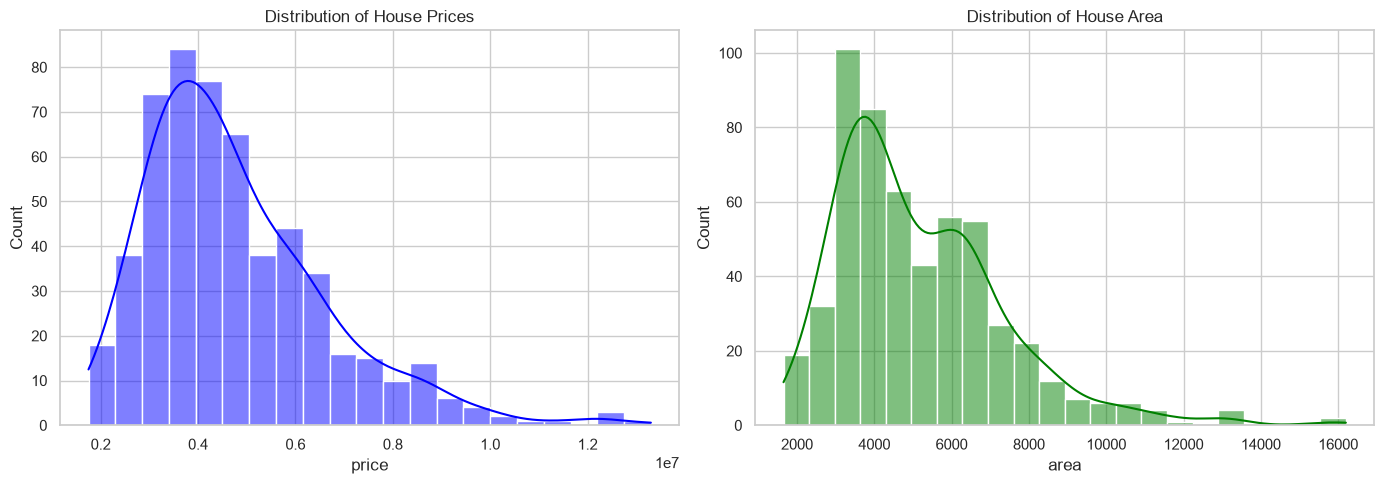

In [130]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize= (14, 5))

sns.histplot(df['price'], kde = True, ax= axes[0], color= 'blue')
axes[0].set_title('Distribution of House Prices')

sns.histplot(df['area'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of House Area')

plt.tight_layout()
plt.show()

In [131]:
print(df
      .filter(items=['price', 'area','furnishingstatus_semi-furnished','furnishingstatus_unfurnished'])
      .sort_values(by=['price'],  ascending=False )
      .head(15)
)

       price   area  furnishingstatus_semi-furnished  \
0   13300000   7420                                0   
2   12250000   9960                                1   
1   12250000   8960                                0   
3   12215000   7500                                0   
4   11410000   7420                                0   
5   10850000   7500                                1   
6   10150000   8580                                1   
7   10150000  16200                                0   
8    9870000   8100                                0   
9    9800000   5750                                0   
10   9800000  13200                                0   
11   9681000   6000                                1   
12   9310000   6550                                1   
13   9240000   3500                                0   
14   9240000   7800                                1   

    furnishingstatus_unfurnished  
0                              0  
2                              0 

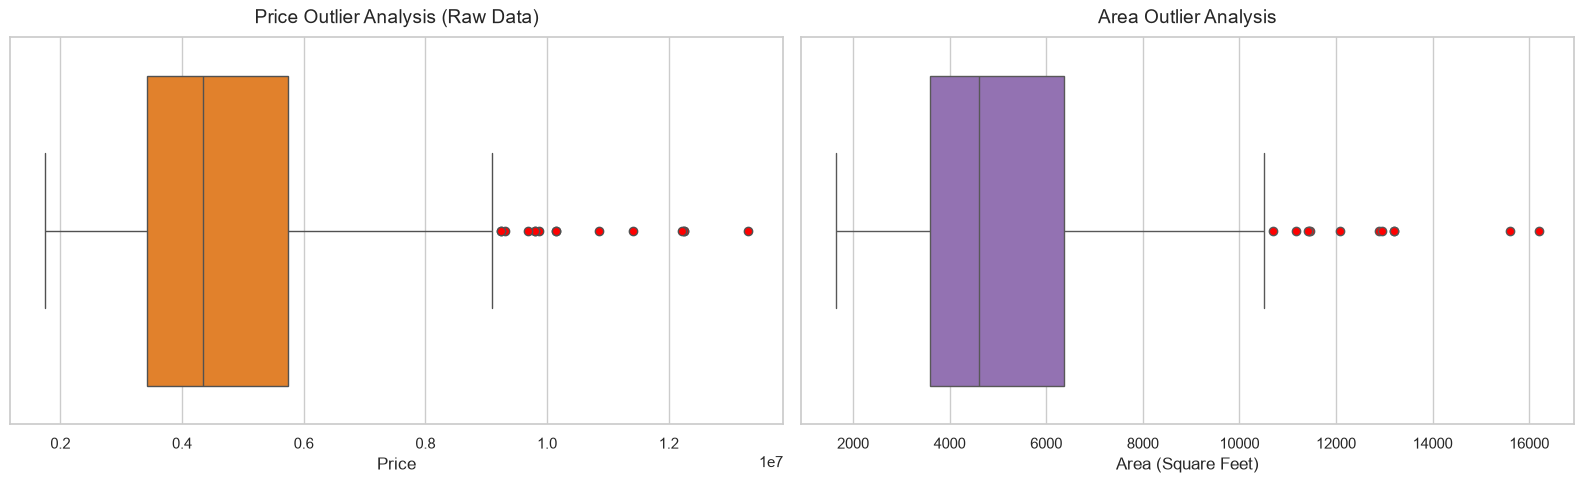

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x='price', ax=axes[0], color='#ff7f0e', 
            flierprops={'markerfacecolor':'red', 'marker':'o', 'markersize': 6})
axes[0].set_title('Price Outlier Analysis (Raw Data)', fontsize=14, pad=10)
axes[0].set_xlabel('Price')


sns.boxplot(data=df, x='area', ax=axes[1], color='#9467bd', 
            flierprops={'markerfacecolor':'red', 'marker':'o', 'markersize': 6})
axes[1].set_title('Area Outlier Analysis', fontsize=14, pad=10)
axes[1].set_xlabel('Area (Square Feet)')

plt.tight_layout()
plt.show()

In [133]:
# Keep only the rows where the area is within the normal statistical boundary
df_clean = df[df['area'] <= 14000]
#df_clean = df
# Check how many rows were dropped
print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_clean)}")



Original rows: 545
Cleaned rows: 543


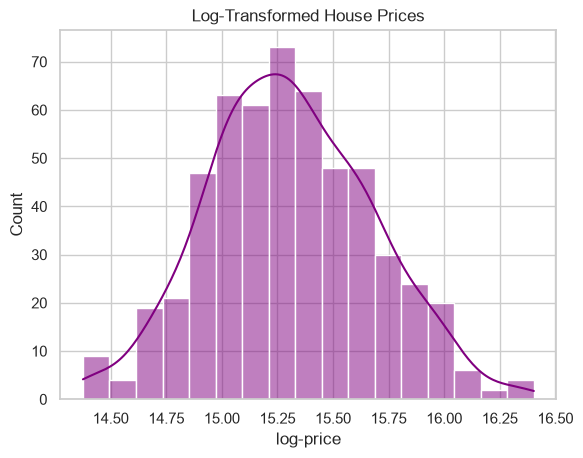

In [134]:
df_clean['log-price'] = np.log1p(df_clean['price'])

sns.histplot(df_clean['log-price'], kde=True, color='purple')
plt.title('Log-Transformed House Prices')
plt.show()

In [135]:
move_col = df_clean.pop('log-price')
df_clean.insert(1, 'log-price', move_col)
df_clean.head()

,price,log-price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,16.403275,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,16.321037,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,16.321037,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,16.318175,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,16.250001,7420,4,1,2,1,1,1,0,1,2,0,0,0


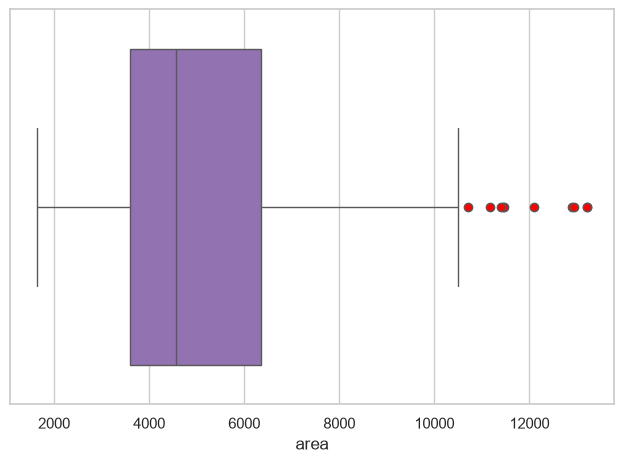

In [136]:
# box-plot for area outlier analysis (df_clean)
sns.boxplot(data=df_clean, x='area',  color='#9467bd', 
            flierprops={'markerfacecolor':'red', 'marker':'o', 'markersize': 6})
axes[1].set_title('Area Outlier Analysis', fontsize=14, pad=10)
axes[1].set_xlabel('Area (Square Feet)')

plt.tight_layout()
plt.show()

In [137]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


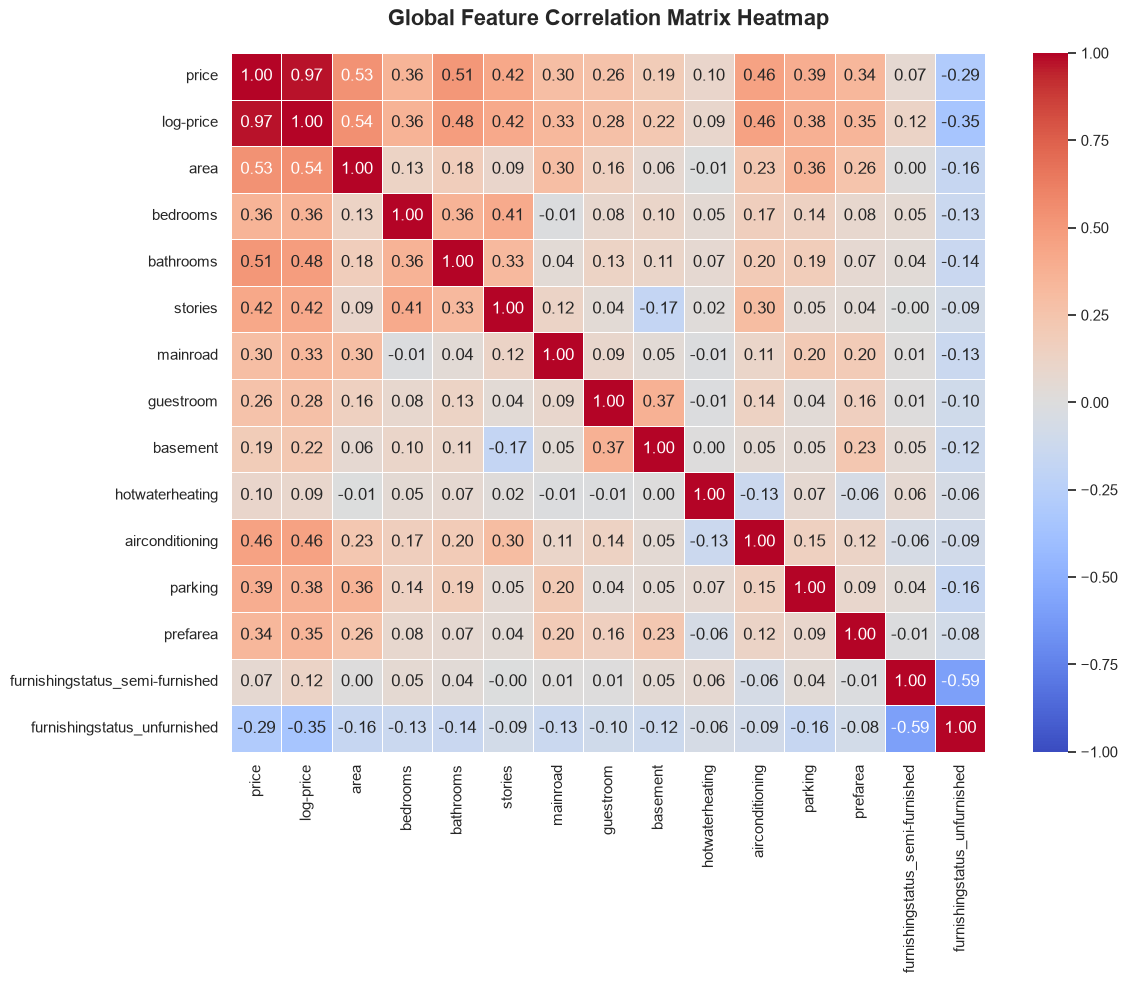

In [138]:
plt.figure(figsize=(12,10))

corr_matrix = df_clean.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', 
            fmt= '.2f', linewidths=0.5, vmin=-1, vmax=1 )

plt.title('Global Feature Correlation Matrix Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


## Feature Engineering
---

In [139]:
# inserting the valuable feature that will help model to better train
df_clean.insert(loc=3, column='total-rooms', value=(df_clean['bedrooms'] + df_clean['bathrooms']))
df_clean.insert(loc=4, column='area-per-bedroom', value=(df_clean['area'] / df_clean['bedrooms']))
df_clean.insert(loc=5, column='luxury-score', value=(df_clean['airconditioning'] + df_clean['prefarea'] ))



In [140]:
df_clean.head()

,price,log-price,area,total-rooms,area-per-bedroom,luxury-score,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,16.403275,7420,6,1855.0,2,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,16.321037,8960,8,2240.0,1,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,16.321037,9960,5,3320.0,1,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,16.318175,7500,6,1875.0,2,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,16.250001,7420,5,1855.0,1,4,1,2,1,1,1,0,1,2,0,0,0


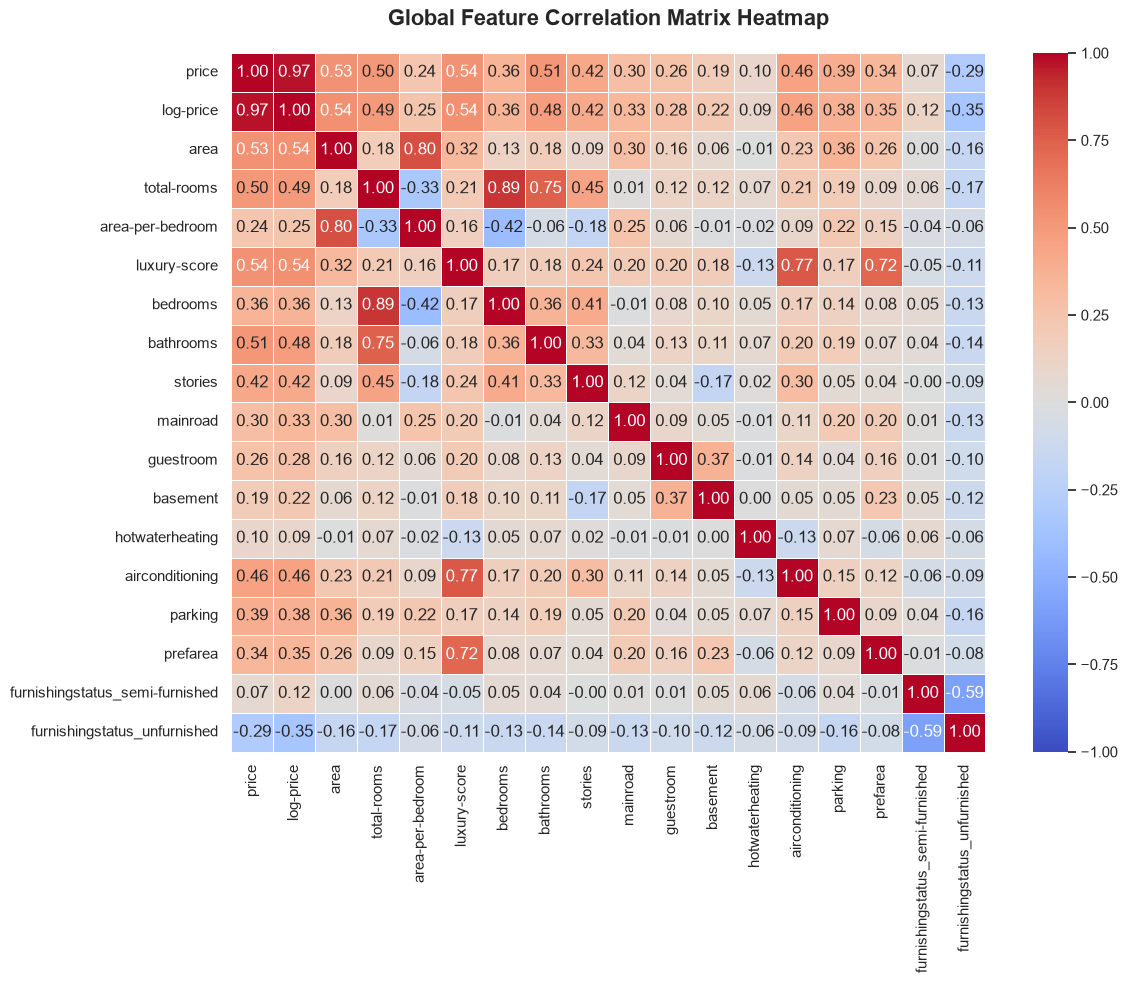

In [141]:
plt.figure(figsize=(12,10))

corr_matrix = df_clean.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', 
            fmt= '.2f', linewidths=0.5, vmin=-1, vmax=1 )

plt.title('Global Feature Correlation Matrix Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [142]:
df_clean.to_csv('..\\datasets\\housing_cleaned_for_train.csv', index= False)

 while performing model training it is necessary to remove redundant columns like price, log-price, bedrooms and bathrooms before feeding as independent features to X and use log-price as target value.